In [2]:
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt




def gather_results(results_folder,
                   epochs = None, classes = None, percents = None, runs = None, methods = None,
                   base = True, retrain = True):

    # gather subdirectories
    all_subdirs = []
    for root, dirs, files in os.walk(results_folder):
        for d in dirs:
            all_subdirs.append(os.path.join(root, d))
            
    if epochs is not None:
        epoch_dirs = [d for d in all_subdirs if "epoch" in d]
        pattern = rf"_({'|'.join(map(str, epochs))})$"
        dirs_to_remove = [d for d in epoch_dirs if not re.search(pattern, d)]
        all_subdirs = [d for d in all_subdirs if d not in dirs_to_remove]

    if not base:
        all_subdirs = [d for d in all_subdirs if "base" not in d]

    if not retrain:
        all_subdirs = [d for d in all_subdirs if "retrain" not in d]

    if methods is not None:
        filtered = []
        for d in all_subdirs:
            d_norm = d.replace('\\', '/')
            if re.search(r'/run_\d+/', d_norm):
                # unlearn method dir — keep only if method name is a path component
                parts = d_norm.split('/')
                if any(p in methods for p in parts):
                    filtered.append(d)
            else:
                # base/retrain dirs — controlled by their own flags, not methods
                filtered.append(d)
        all_subdirs = filtered

    # gather results
    all_results = []
    for subdir in all_subdirs:

        # grab json files in this subdir
        file_paths = glob.glob(os.path.join(subdir, "*.json"))
        
        # remove the config json if it exists
        file_paths = [f for f in file_paths if "config" not in f]
        
        # remove any unnecessary classes, percents, runs
        if classes is not None:
            pattern = rf"class_({'|'.join(map(str, classes))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]

        if percents is not None:
            pattern = rf"percent_({'|'.join(map(str, percents))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]

        if runs is not None:
            pattern = rf"run_({'|'.join(map(str, runs))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]
        
        # Check if anything is left AFTER filtering
        if not file_paths:
            continue
        
        # add jsons for these file paths
        all_jsons = []
        for f in file_paths:
            data = pd.read_json(f, typ='series')
            
            # add class if none
            match = re.search(r'class_(\d+)', f)
            if match:
                data['class'] = int(match.group(1))
            else:
                data['class'] = -99  # default value if no match

            # add percent if none
            match = re.search(r'percent_(\d+)', f)
            if match:
                data['percent'] = int(match.group(1))
            else:
                data['percent'] = -99  # default value if no match

            # add epoch if none
            match = re.search(r'base', f)
            if match:
                data['epoch'] = -99

            match = re.search(r'retrain', f)
            if match:
                data['epoch'] = -98

            # add run if none
            match = re.search(r'run_(\d+)', f)
            if match:
                data['run'] = int(match.group(1))
            else:
                data['run'] = -99  # default value if no match

            # add method from path structure (run_N/METHOD/epoch_N)
            f_norm = f.replace('\\', '/')
            match = re.search(r'/run_\d+/([^/]+)/epoch', f_norm)
            if match:
                data['method'] = match.group(1)
            elif '/base/' in f_norm:
                data['method'] = 'base'
            elif '/retrain/' in f_norm:
                data['method'] = 'retrain'
            else:
                data['method'] = 'unknown'

            all_jsons.append(data)

        # and concat and append to main df
        df = pd.concat(all_jsons, axis=1).T
        all_results.append(df)
    if not all_results:
        raise ValueError("No results - check settings")
    final_df = pd.concat(all_results, axis=0)


    if "MIA" in final_df.columns:

        expanded_MIA = pd.json_normalize(final_df['MIA'])

        # json_normalize resets the index, so you MUST align it with your original dataframe
        expanded_MIA.index = final_df.index

        # Optional prefixing
        expanded_MIA = expanded_MIA.add_prefix('MIA_')

        # 2. Drop the original nested column and concatenate
        final_df = pd.concat([final_df.drop('MIA', axis=1), expanded_MIA], axis=1)

    return final_df


def results_scatterplot(final_df, x_metric, y_metric, 
                        color_by = "epoch", 
                        base_color = "black", retain_color = "purple"
                        ):

    
    # set up colors — use key=str to safely sort mixed-type columns (e.g. method strings)
    unique_vals = sorted(final_df[color_by].unique(), key=str)
    colors_list = plt.cm.tab20.colors
    palette_dict = {}
    color_idx = 0
    for val in unique_vals:
        if val == -99 or val == "base":
            palette_dict[val] = base_color
        elif val == -98 or val == "retrain":
            palette_dict[val] = retain_color
        else:
            # Use modulo to cycle through tab20 if you have more than 20 values
            palette_dict[val] = colors_list[color_idx % len(colors_list)]
            color_idx += 1

    # plot
    plt.clf()
    sns.set_style("whitegrid")
    sns.scatterplot(
        data=final_df, 
        x=x_metric, 
        y=y_metric, 
        hue=color_by, 
        palette=palette_dict,  # Use the mapping dictionary here
        alpha=0.7,
        edgecolor=None
    )
    # Formatting
    plt.title(f"{x_metric} vs. {y_metric}")
    plt.xlabel(x_metric.capitalize().replace("_", " "))
    plt.ylabel(y_metric.capitalize().replace("_", " "))
    handles, labels = plt.gca().get_legend_handles_labels()
    # Replace numeric sentinels with readable labels
    new_labels = ["base" if label in ("-99", "-99.0") else "retrain" if label in ("-98", "-98.0") else label for label in labels]
    plt.legend(title=color_by.capitalize(), handles = handles, labels = new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.xlim(.6, .95)
    # plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [5]:
results = gather_results("results/seed_4", base=True, retrain=True) 
results

,acc,loss,entropy,m_entropy,threshold_MIA,type,class,percent,epoch,run,...,MIA_confidence_no_class.retain_test_member,MIA_confidence_no_class.forget_non_member,MIA_entropy_class.retain_test_member,MIA_entropy_class.forget_non_member,MIA_entropy_no_class.retain_test_member,MIA_entropy_no_class.forget_non_member,MIA_m_entropy_class.retain_test_member,MIA_m_entropy_class.forget_non_member,MIA_m_entropy_no_class.retain_test_member,MIA_m_entropy_no_class.forget_non_member
0,"{'forget': 99.3399999633789, 'retain': 99.7199...","{'forget': 0.017622118052840002, 'retain': 0.0...","{'forget': 0.030619158607721002, 'retain': 0.0...","{'forget': 0.016315396720170003, 'retain': 0.0...",{'class': {'confidence': {'retain_test_member'...,base,5,-99,-99,-99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,"{'forget': 0.0, 'retain': 99.78888888888889, '...","{'forget': 14.410597355651856, 'retain': 0.007...","{'forget': 0.215436186861991, 'retain': 0.0167...","{'forget': 20.415070721435548, 'retain': 0.006...",{'class': {'confidence': {'retain_test_member'...,retrain,5,-99,-98,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"{'forget': 0.0, 'retain': 99.8, 'test': 84.500...","{'forget': 14.855117700195313, 'retain': 0.007...","{'forget': 0.21298102817535403, 'retain': 0.01...","{'forget': 20.784607232666016, 'retain': 0.006...",{'class': {'confidence': {'retain_test_member'...,retrain,5,-99,-98,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"{'forget': 0.0, 'retain': 99.76444444444445, '...","{'forget': 14.701583108520508, 'retain': 0.008...","{'forget': 0.21859668965339601, 'retain': 0.01...","{'forget': 20.47347774963379, 'retain': 0.0079...",{'class': {'confidence': {'retain_test_member'...,retrain,5,-99,-98,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,NaN,NaN,NaN,NaN,NaN,unlearn,5,-99,1,1,...,0.949556,0.3112,0.936333,0.0,0.905333,0.4126,0.947222,0.0,0.950222,0.3112
0,NaN,NaN,NaN,NaN,NaN,unlearn,5,-99,2,1,...,0.954111,0.3150,0.932889,0.0,0.919000,0.3884,0.950333,0.0,0.942222,0.3454
0,NaN,NaN,NaN,NaN,NaN,unlearn,5,-99,3,1,...,0.944111,0.3508,0.931778,0.0,0.921444,0.3998,0.951667,0.0,0.943000,0.3530
0,NaN,NaN,NaN,NaN,NaN,unlearn,5,-99,4,1,...,0.939444,0.3682,0.932333,0.0,0.922000,0.4048,0.952889,0.0,0.936333,0.3778
0,NaN,NaN,NaN,NaN,NaN,unlearn,5,-99,5,1,...,0.955556,0.3652,0.940556,0.0,0.925000,0.4288,0.955222,0.0,0.952222,0.3750
0,NaN,NaN,NaN,NaN,NaN,unlearn,5,-99,6,1,...,0.954667,0.3672,0.943222,0.0,0.936111,0.4060,0.960000,0.0,0.959000,0.3574


ValueError: cannot reindex on an axis with duplicate labels

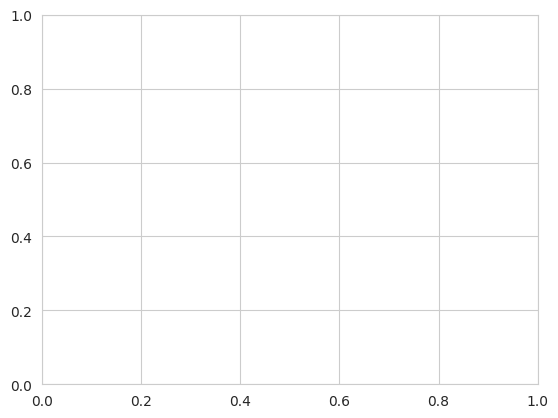

In [4]:
results = gather_results("results/seed_4", base=True, retrain=True) 
                        #  epochs = [-99, 0, 1, 2, 3, 4, 5, 6])
results_scatterplot(
    results, 
    x_metric = "forget_acc", y_metric = "retain_acc", 
    color_by = "method"
    )